In [25]:
import pandas as pd
import seaborn as sns
import wandb
import wandb.apis.public

sns.set_theme(style="darkgrid")

legend_to_run_paths = {
      "Naive ID=10": [
        "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_25_14_19_50_0000--s-0_qf25_id10",
        "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_25_14_19_54_0000--s-1_qf25_id10",
        "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_25_14_19_57_0000--s-2_qf25_id10",
        "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_26_03_10_40_0000--s-3_qf25_id10",
        "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_26_03_10_44_0000--s-4_qf25_id10",
        "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_26_03_10_44_0000--s-5_qf25_id10"
      ],
      "Naive ID=10 (PA)": [
        "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_25_14_12_01_0000--s-0_qf25_id10_pca",
        "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_25_14_12_07_0000--s-1_qf25_id10_pca",
        "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_25_14_12_11_0000--s-2_qf25_id10_pca",
        "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_26_03_13_18_0000--s-3_qf25_id10_pca",
        "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_26_03_13_18_0000--s-4_qf25_id10_pca",
        "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_26_03_13_17_0000--s-5_qf25_id10_pca"
      ],
      "Naive ID=10 (US)": [
        "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_25_14_08_58_0000--s-0_qf25_id10_rld5",
        "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_25_14_09_01_0000--s-1_qf25_id10_rld5",
        "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_25_14_09_01_0000--s-2_qf25_id10_rld5",
        "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_26_03_13_58_0000--s-3_qf25_id10_rld5",
        "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_26_03_13_58_0000--s-4_qf25_id10_rld5",
        "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_26_03_13_58_0000--s-5_qf25_id10_rld5"
      ],
      "Naive ID=10 (PA, US)": [
        "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_25_14_09_09_0000--s-0_qf25_id10_rld5_pca",
        "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_25_14_09_09_0000--s-1_qf25_id10_rld5_pca",
        "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_25_14_12_01_0000--s-2_qf25_id10_rld5_pca",
        "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_26_03_13_58_0000--s-3_qf25_id10_rld5_pca",
        "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_26_03_13_58_0000--s-4_qf25_id10_rld5_pca",
        "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_26_03_13_58_0000--s-5_qf25_id10_rld5_pca"
      ],
      # "Naive ID=20": [
      #   "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_25_14_12_21_0000--s-0_qf25_id20",
      #   "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_25_14_12_22_0000--s-1_qf25_id20",
      #   "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_25_14_12_20_0000--s-2_qf25_id20",
      #   "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_26_03_10_44_0000--s-3_qf25_id20",
      #   "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_26_03_10_44_0000--s-4_qf25_id20",
      #   "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_26_03_10_44_0000--s-5_qf25_id20"
      # ],
      # "Naive ID=20 (PA)": [
      #   "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_25_14_12_11_0000--s-0_qf25_id20_pca",
      #   "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_25_14_12_20_0000--s-1_qf25_id20_pca",
      #   "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_25_14_12_16_0000--s-2_qf25_id20_pca",
      #   "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_26_03_13_17_0000--s-3_qf25_id20_pca",
      #   "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_26_03_13_17_0000--s-4_qf25_id20_pca",
      #   "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_26_03_13_17_0000--s-5_qf25_id20_pca"
      # ],
      # "Naive ID=20 (US)": [
      #   "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_25_14_12_19_0000--s-0_qf25_id20_rld10",
      #   "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_25_14_12_19_0000--s-1_qf25_id20_rld10",
      #   "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_25_14_12_19_0000--s-2_qf25_id20_rld10",
      #   "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_26_03_14_05_0000--s-3_qf25_id20_rld10",
      #   "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_26_03_14_05_0000--s-4_qf25_id20_rld10",
      #   "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_26_03_14_04_0000--s-5_qf25_id20_rld10"
      # ],
      # "Naive ID=20 (PA, US)": [
      #   "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_25_14_12_19_0000--s-0_qf25_id20_rld10_pca",
      #   "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_25_14_12_19_0000--s-1_qf25_id20_rld10_pca",
      #   "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_25_14_12_18_0000--s-2_qf25_id20_rld10_pca",
      #   "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_26_03_14_04_0000--s-3_qf25_id20_rld10_pca",
      #   "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_26_03_14_04_0000--s-4_qf25_id20_rld10_pca",
      #   "eharrison-university-of-california-berkeley/DSRL_pi0_InferenceDelay_Aloha_Full/dsrl_pi0_aloha_utd25_2026_05_26_03_14_04_0000--s-5_qf25_id20_rld10_pca"
      # ],
}

metric = "evaluation/success_rate"

api = wandb.Api()
legend_to_runs: dict[str, list[wandb.apis.public.Run]] = {
    leg: [api.run(p) for p in paths] for leg, paths in legend_to_run_paths.items()
}
dfs = []
for legend, runs in legend_to_runs.items():
    for run in runs:
        metric_df = run.history(keys=[metric])
        metric_df = metric_df.drop([0])
        metric_df["legend"] = legend
        dfs.append(metric_df)

agg_df = pd.concat(dfs)

print(agg_df)

     _step  evaluation/success_rate                legend
1    10000                     0.00           Naive ID=10
2    20000                     0.00           Naive ID=10
3    30000                     0.00           Naive ID=10
4    40000                     0.00           Naive ID=10
5    50000                     0.00           Naive ID=10
..     ...                      ...                   ...
56  560000                     0.14  Naive ID=10 (PA, US)
57  570000                     0.02  Naive ID=10 (PA, US)
58  580000                     0.12  Naive ID=10 (PA, US)
59  590000                     0.04  Naive ID=10 (PA, US)
60  600000                     0.14  Naive ID=10 (PA, US)

[1459 rows x 3 columns]


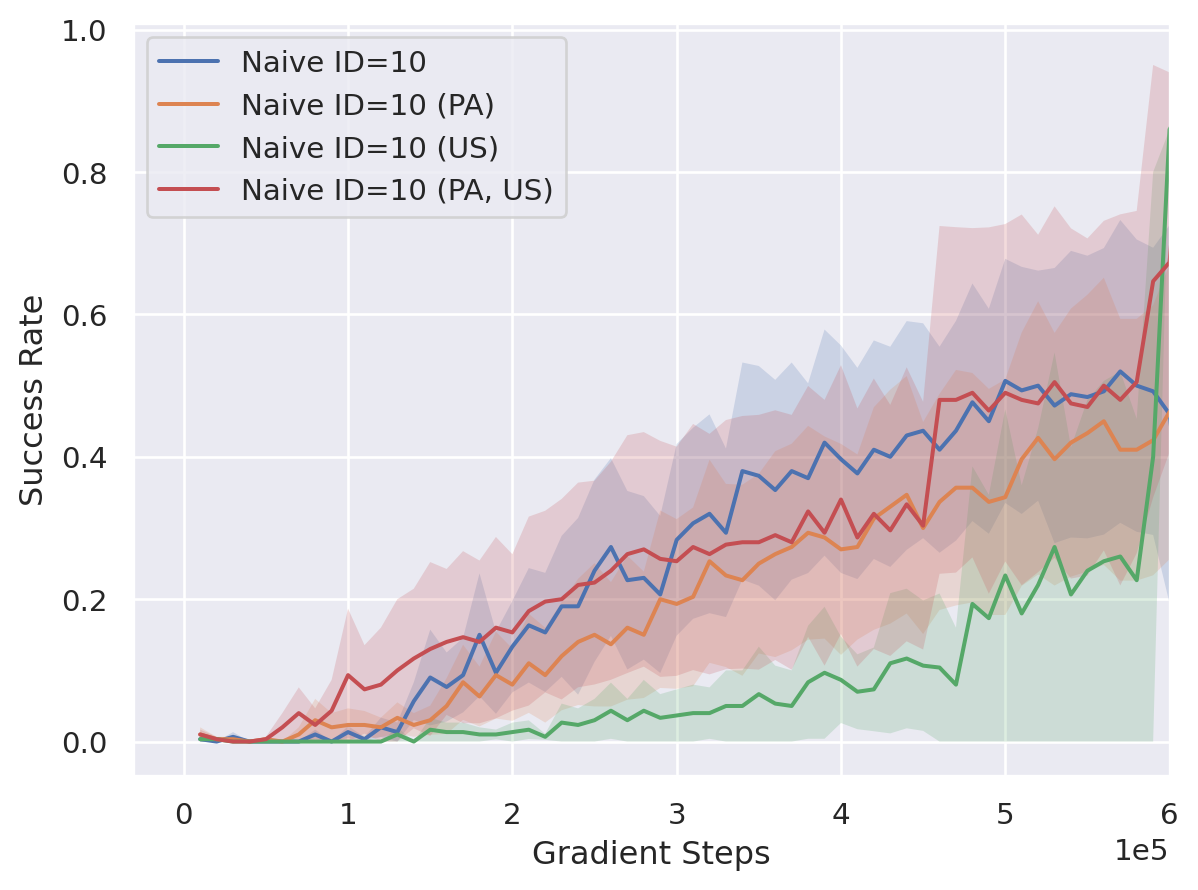

In [26]:
import matplotlib.ticker
import seaborn.objects as so

sci_formatter = matplotlib.ticker.ScalarFormatter()
sci_formatter.set_scientific(True)
sci_formatter.set_powerlimits((0, 0))

plot = (
    so.Plot(agg_df, x="_step", y="evaluation/success_rate", color="legend")
    .add(so.Line(), so.Agg())
    .add(so.Band(), so.Est(errorbar="se"))
    .scale(x=so.Continuous().label(sci_formatter))
    .limit(x=(None, 600_000))
    .label(x="Gradient Steps", y="Success Rate")
)
p = plot.plot()
if p._figure.legends:
    legend = p._figure.legends.pop(0)
    p._figure.axes[0].legend(
        legend.legend_handles,
        [t.get_text() for t in legend.texts],
        loc="upper left",
    )
p